<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/massTransfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Molecular diffusion and mass-transfer screening with NeqSim

**Audience.** Process engineers and advanced students who need transport-property inputs for
absorbers, separators, membranes, pipelines, or other rate-based models.

**Learning objectives.** By the end, you will be able to:

1. calculate binary and effective multicomponent diffusion coefficients with NeqSim;
2. compare supported gas- and liquid-phase diffusivity correlations;
3. verify temperature, pressure, phase, and matrix-consistency trends;
4. convert molecular diffusivity into film and convective mass-transfer coefficients; and
5. perform a transparent area screen while recognizing the limits of correlation-based design.

All pressures are absolute. Diffusion coefficients use m²/s, concentrations use mol/m³, molar fluxes
use mol/(m² s), and mass-transfer coefficients use m/s.

In [1]:
import importlib.util
import platform
import subprocess
import sys
from importlib.metadata import version

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim.thermo import TPflash, fluid

java_result = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
)
runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            version("neqsim"),
            platform.python_version(),
            java_result.stderr.splitlines()[0],
        ],
    }
)
display(runtime_table)

  Runtime                               Version
0  NeqSim                                3.16.0
1  Python                               3.12.13
2    Java  openjdk version "17.0.19" 2026-04-21


## 1. Engineering case and assumptions

The base case is a dilute CO₂-bearing natural-gas surrogate at 25°C and atmospheric pressure. The
composition is synthetic and public so the calculation is reproducible. The Soave-Redlich-Kwong
(SRK) equation of state supplies phase equilibrium and density; NeqSim's physical-property package
supplies viscosity and diffusivity.

This is an educational screening model. A final design should use a fluid model and transport
correlation validated against measurements at the actual composition, pressure, and temperature.

In [2]:
gas_composition = {
    "methane": 0.80,
    "ethane": 0.10,
    "CO2": 0.05,
    "nitrogen": 0.05,
}
base_temperature_k = 298.15
base_pressure_bara = 1.01325

composition_sum = sum(gas_composition.values())
assert abs(composition_sum - 1.0) < 1.0e-12

case_table = pd.DataFrame(
    {
        "Component": list(gas_composition.keys()),
        "Feed mole fraction [mol/mol]": list(gas_composition.values()),
    }
)
display(case_table)
print(f"Composition sum: {composition_sum:.6f} mol/mol")

  Component  Feed mole fraction [mol/mol]
0   methane                          0.80
1    ethane                          0.10
2       CO2                          0.05
3  nitrogen                          0.05
Composition sum: 1.000000 mol/mol


## 2. Fick and Maxwell-Stefan descriptions

For one-dimensional binary diffusion, Fick's law is

$$
J_A = -D_{AB} c_t \frac{d x_A}{d z}
$$

Here $J_A$ is the molar flux of species $A$, $D_{AB}$ is its binary diffusion coefficient, $c_t$ is
total molar concentration, $x_A$ is mole fraction, and $z$ is distance. Multicomponent mixtures are
more rigorously described by Maxwell-Stefan driving-force relations. A convenient mixture-averaged
coefficient for species $i$ is

$$
D_i^{eff} = \frac{1-x_i}{\sum_{j \ne i} x_j / D_{ij}}
$$

NeqSim stores the binary matrix and calculates this effective coefficient. We will independently
reconstruct it as a consistency check.

In [3]:
def build_srk_state(temperature_k, pressure_bara, composition):
    state = fluid("srk")
    state.setTemperature(temperature_k, "K")
    state.setPressure(pressure_bara, "bara")

    for component_name, amount_mol in composition.items():
        state.addComponent(component_name, amount_mol)

    state.setMixingRule("classic")
    TPflash(state)
    state.initPhysicalProperties()
    return state


def initialize_diffusivity(phase, model_name):
    properties = phase.getPhysicalProperties()
    properties.setDiffusionCoefficientModel(model_name)
    properties.init(phase)
    properties.diffusivityCalc.calcEffectiveDiffusionCoefficients()
    return properties


gas_state = build_srk_state(
    base_temperature_k,
    base_pressure_bara,
    gas_composition,
)
gas_phase = gas_state.getPhase("gas")

## 3. Base gas state

A transport calculation should begin with phase diagnostics. Diffusivity models are phase-specific,
so silently applying a gas correlation to a liquid phase would be a serious error. The table below
also reports the density and dynamic viscosity used later in Reynolds and Schmidt numbers.

In [4]:
gas_properties = gas_phase.getPhysicalProperties()
gas_component_rows = []

for component_index in range(gas_phase.getNumberOfComponents()):
    component = gas_phase.getComponent(component_index)
    gas_component_rows.append(
        {
            "Component": str(component.getComponentName()),
            "Gas mole fraction [mol/mol]": component.getx(),
        }
    )

gas_phase_table = pd.DataFrame(gas_component_rows)
gas_state_table = pd.DataFrame(
    {
        "Property": ["Phase count", "Density", "Dynamic viscosity"],
        "Value": [
            gas_state.getNumberOfPhases(),
            gas_properties.getDensity(),
            gas_properties.getViscosity(),
        ],
        "Unit": ["-", "kg/m³", "Pa s"],
    }
)
display(gas_phase_table)
display(gas_state_table)

  Component  Gas mole fraction [mol/mol]
0   methane                         0.80
1    ethane                         0.10
2       CO2                         0.05
3  nitrogen                         0.05
            Property     Value   Unit
0        Phase count  1.000000      -
1            Density  0.796423  kg/m³
2  Dynamic viscosity  0.000012   Pa s


## 4. Gas diffusivity correlation comparison

Transport correlations encode different molecular-property approximations. Agreement is useful, but
it does not prove accuracy. We compare four gas models supported by NeqSim for CO₂ diffusing through
methane. Fuller-Schettler-Giddings is retained as the base screening correlation.

                       Model  ...  Effective D(CO₂) [m²/s]
0             Chapman-Enskog  ...                 0.000016
1                  Wilke Lee  ...                 0.000017
2  Fuller-Schettler-Giddings  ...                 0.000017
3                        CSP  ...                 0.000018

[4 rows x 3 columns]


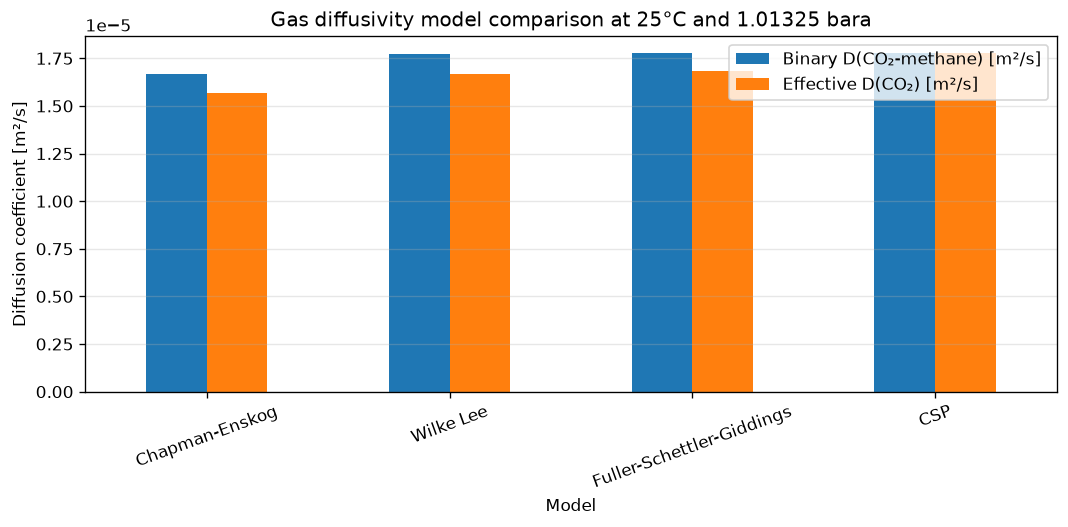

In [5]:
gas_model_names = [
    "Chapman-Enskog",
    "Wilke Lee",
    "Fuller-Schettler-Giddings",
    "CSP",
]
gas_model_rows = []

for model_name in gas_model_names:
    model_properties = initialize_diffusivity(gas_phase, model_name)
    binary_diffusivity = model_properties.getDiffusionCoefficient("CO2", "methane")
    effective_diffusivity = model_properties.getEffectiveDiffusionCoefficient("CO2")
    gas_model_rows.append(
        {
            "Model": model_name,
            "Binary D(CO₂-methane) [m²/s]": binary_diffusivity,
            "Effective D(CO₂) [m²/s]": effective_diffusivity,
        }
    )

gas_model_table = pd.DataFrame(gas_model_rows)
display(gas_model_table)

ax = gas_model_table.plot.bar(
    x="Model",
    y=["Binary D(CO₂-methane) [m²/s]", "Effective D(CO₂) [m²/s]"],
    figsize=(9, 4.5),
    rot=20,
)
ax.set_ylabel("Diffusion coefficient [m²/s]")
ax.set_title("Gas diffusivity model comparison at 25°C and 1.01325 bara")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The correlations cluster closely for this low-pressure gas, while the effective coefficient differs
from the CO₂-methane binary value because ethane and nitrogen also contribute frictional resistance.
That distinction matters when a binary coefficient is inserted into a multicomponent film model.

In [6]:
base_properties = initialize_diffusivity(
    gas_phase,
    "Fuller-Schettler-Giddings",
)
component_names = [
    str(gas_phase.getComponent(index).getComponentName())
    for index in range(gas_phase.getNumberOfComponents())
]
gas_mole_fractions = np.array(
    [
        gas_phase.getComponent(index).getx()
        for index in range(gas_phase.getNumberOfComponents())
    ]
)
binary_matrix = np.array(
    [
        [
            base_properties.getDiffusionCoefficient(row_index, column_index)
            for column_index in range(gas_phase.getNumberOfComponents())
        ]
        for row_index in range(gas_phase.getNumberOfComponents())
    ]
)

co2_index = component_names.index("CO2")
manual_denominator = sum(
    gas_mole_fractions[index] / binary_matrix[co2_index, index]
    for index in range(gas_phase.getNumberOfComponents())
    if index != co2_index
)
manual_effective_co2 = (1.0 - gas_mole_fractions[co2_index]) / manual_denominator
neqsim_effective_co2 = base_properties.getEffectiveDiffusionCoefficient(co2_index)
effective_relative_error = abs(manual_effective_co2 - neqsim_effective_co2)
effective_relative_error /= neqsim_effective_co2

binary_matrix_table = pd.DataFrame(
    binary_matrix,
    index=component_names,
    columns=component_names,
)
display(binary_matrix_table)
print(f"Manual effective CO₂ diffusivity: {manual_effective_co2:.8e} m²/s")
print(f"NeqSim effective CO₂ diffusivity: {neqsim_effective_co2:.8e} m²/s")
print(f"Relative reconstruction error: {effective_relative_error:.3e}")

           methane    ethane       CO2  nitrogen
methane   0.000022  0.000016  0.000018  0.000022
ethane    0.000016  0.000011  0.000012  0.000015
CO2       0.000018  0.000012  0.000013  0.000016
nitrogen  0.000022  0.000015  0.000016  0.000020
Manual effective CO₂ diffusivity: 1.68175223e-05 m²/s
NeqSim effective CO₂ diffusivity: 1.68175223e-05 m²/s
Relative reconstruction error: 0.000e+00


## 5. Temperature sensitivity

Gas molecules move faster as temperature rises, so dilute-gas diffusivity should increase when
pressure and composition remain fixed. The sweep rebuilds and flashes every state rather than
reusing stale physical properties.

In [7]:
temperature_values_k = np.array([275.0, 290.0, 305.0, 320.0, 335.0, 350.0])
temperature_diffusivities = []

for temperature_k in temperature_values_k:
    temperature_state = build_srk_state(
        temperature_k,
        base_pressure_bara,
        gas_composition,
    )
    temperature_phase = temperature_state.getPhase("gas")
    temperature_properties = initialize_diffusivity(
        temperature_phase,
        "Fuller-Schettler-Giddings",
    )
    temperature_diffusivities.append(
        temperature_properties.getDiffusionCoefficient("CO2", "methane")
    )

temperature_table = pd.DataFrame(
    {
        "Temperature [K]": temperature_values_k,
        "D(CO₂-methane) [m²/s]": temperature_diffusivities,
    }
)
display(temperature_table)

   Temperature [K]  D(CO₂-methane) [m²/s]
0            275.0               0.000015
1            290.0               0.000017
2            305.0               0.000018
3            320.0               0.000020
4            335.0               0.000022
5            350.0               0.000024


## 6. Pressure sensitivity

At dilute-gas conditions, diffusivity is expected to decrease approximately with inverse pressure.
The next sweep stays within a single gas phase and combines both trend studies in one figure.

   Pressure [bara]  D(CO₂-methane) [m²/s]
0          1.01325               0.000018
1          2.00000               0.000009
2          4.00000               0.000004
3          7.00000               0.000003
4         10.00000               0.000002


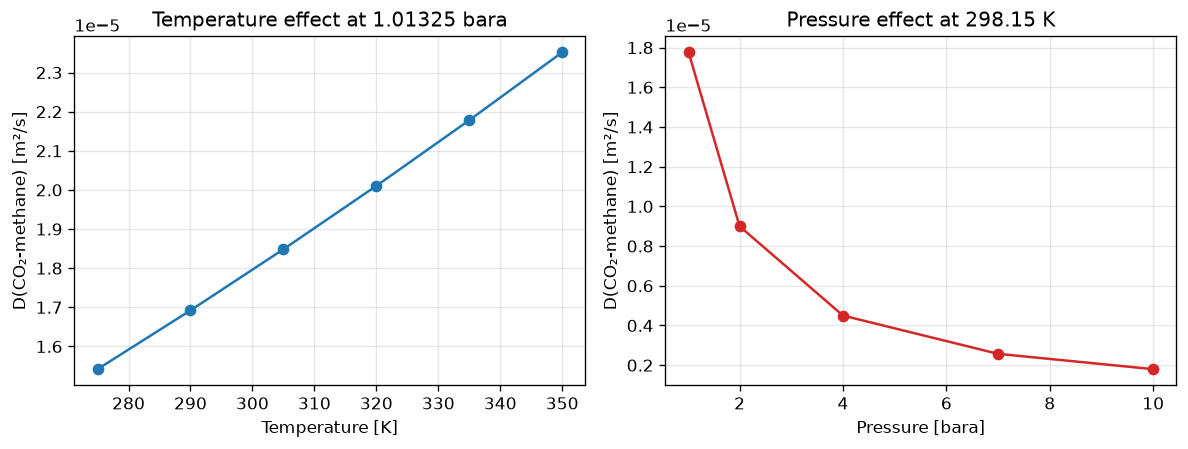

In [8]:
pressure_values_bara = np.array([1.01325, 2.0, 4.0, 7.0, 10.0])
pressure_diffusivities = []

for pressure_bara in pressure_values_bara:
    pressure_state = build_srk_state(
        base_temperature_k,
        pressure_bara,
        gas_composition,
    )
    pressure_phase = pressure_state.getPhase("gas")
    pressure_properties = initialize_diffusivity(
        pressure_phase,
        "Fuller-Schettler-Giddings",
    )
    pressure_diffusivities.append(
        pressure_properties.getDiffusionCoefficient("CO2", "methane")
    )

pressure_table = pd.DataFrame(
    {
        "Pressure [bara]": pressure_values_bara,
        "D(CO₂-methane) [m²/s]": pressure_diffusivities,
    }
)
display(pressure_table)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(temperature_values_k, temperature_diffusivities, marker="o")
axes[0].set_xlabel("Temperature [K]")
axes[0].set_ylabel("D(CO₂-methane) [m²/s]")
axes[0].set_title("Temperature effect at 1.01325 bara")
axes[1].plot(pressure_values_bara, pressure_diffusivities, marker="o", color="tab:red")
axes[1].set_xlabel("Pressure [bara]")
axes[1].set_ylabel("D(CO₂-methane) [m²/s]")
axes[1].set_title("Pressure effect at 298.15 K")

for axis in axes:
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Stagnant-film calculation

For a film of thickness $\delta$ with an approximately linear composition profile, the magnitude of
the diffusive flux is

$$
N_{CO_2} = D_{CO_2}^{eff} c_t \frac{x_b-x_i}{\delta}
$$

The bulk and interface mole fractions are $x_b$ and $x_i$. The coefficient $k=D/\delta$ isolates
transport from the driving force. We calculate $c_t$ from NeqSim density and molar mass rather than
assuming an ideal gas.

In [9]:
gas_density_kg_per_m3 = gas_properties.getDensity()
gas_molar_mass_kg_per_mol = gas_phase.getMolarMass()
total_concentration_mol_per_m3 = gas_density_kg_per_m3 / gas_molar_mass_kg_per_mol
film_thickness_m = 0.5e-3
bulk_co2_fraction = gas_phase.getComponent("CO2").getx()
interface_co2_fraction = 0.01
film_mass_transfer_coefficient = neqsim_effective_co2 / film_thickness_m
co2_molar_flux = film_mass_transfer_coefficient * total_concentration_mol_per_m3
co2_molar_flux *= bulk_co2_fraction - interface_co2_fraction
methane_counterflux = -co2_molar_flux
equimolar_flux_residual = co2_molar_flux + methane_counterflux

film_table = pd.DataFrame(
    {
        "Quantity": [
            "Total molar concentration",
            "Film thickness",
            "Effective CO₂ diffusivity",
            "Film coefficient",
            "CO₂ molar flux",
            "Equimolar flux residual",
        ],
        "Value": [
            total_concentration_mol_per_m3,
            film_thickness_m,
            neqsim_effective_co2,
            film_mass_transfer_coefficient,
            co2_molar_flux,
            equimolar_flux_residual,
        ],
        "Unit": ["mol/m³", "m", "m²/s", "m/s", "mol/(m² s)", "mol/(m² s)"],
    }
)
display(film_table)

                    Quantity      Value        Unit
0  Total molar concentration  40.962854      mol/m³
1             Film thickness   0.000500           m
2  Effective CO₂ diffusivity   0.000017        m²/s
3           Film coefficient   0.033635         m/s
4             CO₂ molar flux   0.055111  mol/(m² s)
5    Equimolar flux residual   0.000000  mol/(m² s)


## 8. Convective coefficient from dimensionless groups

Molecular diffusivity enters equipment-scale correlations through the Schmidt number. For turbulent
flow in a smooth circular tube, a common screening relation is

$$
Re = \frac{\rho u d}{\mu}, \qquad Sc = \frac{\mu}{\rho D}
$$

$$
Sh = 0.023 Re^{0.83} Sc^{0.33}, \qquad k_c = \frac{Sh D}{d}
$$

Here $u$ is superficial velocity in m/s, $d$ is diameter in m, $\rho$ is kg/m³, and $\mu$ is Pa s.
The correlation is used only when $Re>10{,}000$; entry effects and roughness are neglected.

In [10]:
pipe_velocity_m_per_s = 8.0
pipe_diameter_m = 0.10
gas_viscosity_pa_s = gas_properties.getViscosity()
reynolds_number = (
    gas_density_kg_per_m3
    * pipe_velocity_m_per_s
    * pipe_diameter_m
    / gas_viscosity_pa_s
)
schmidt_number = gas_viscosity_pa_s / (
    gas_density_kg_per_m3 * neqsim_effective_co2
)
sherwood_number = 0.023 * reynolds_number**0.83 * schmidt_number**0.33
convective_mass_transfer_coefficient = (
    sherwood_number * neqsim_effective_co2 / pipe_diameter_m
)

dimensionless_table = pd.DataFrame(
    {
        "Quantity": ["Reynolds number", "Schmidt number", "Sherwood number", "Coefficient"],
        "Value": [
            reynolds_number,
            schmidt_number,
            sherwood_number,
            convective_mass_transfer_coefficient,
        ],
        "Unit": ["-", "-", "-", "m/s"],
    }
)
display(dimensionless_table)

          Quantity         Value Unit
0  Reynolds number  54554.620624    -
1   Schmidt number      0.871960    -
2  Sherwood number    187.785406    -
3      Coefficient      0.031581  m/s


### Velocity sensitivity

The diffusivity is a molecular property at the fixed thermodynamic state, while the convective
coefficient changes with hydrodynamics. The curve therefore should increase smoothly with velocity
inside the stated turbulent range.

In [11]:
velocity_values_m_per_s = np.linspace(2.0, 15.0, 14)
reynolds_values = (
    gas_density_kg_per_m3
    * velocity_values_m_per_s
    * pipe_diameter_m
    / gas_viscosity_pa_s
)
sherwood_values = 0.023 * reynolds_values**0.83 * schmidt_number**0.33
coefficient_values_m_per_s = (
    sherwood_values * neqsim_effective_co2 / pipe_diameter_m
)

velocity_table = pd.DataFrame(
    {
        "Velocity [m/s]": velocity_values_m_per_s,
        "Reynolds number [-]": reynolds_values,
        "Mass-transfer coefficient [m/s]": coefficient_values_m_per_s,
    }
)
display(velocity_table)

    Velocity [m/s]  Reynolds number [-]  Mass-transfer coefficient [m/s]
0              2.0         13638.655156                         0.009993
1              3.0         20457.982734                         0.013992
2              4.0         27277.310312                         0.017765
3              5.0         34096.637890                         0.021380
4              6.0         40915.965468                         0.024873
5              7.0         47735.293046                         0.028268
6              8.0         54554.620624                         0.031581
7              9.0         61373.948201                         0.034824
8             10.0         68193.275779                         0.038007
9             11.0         75012.603357                         0.041135
10            12.0         81831.930935                         0.044216
11            13.0         88651.258513                         0.047253
12            14.0         95470.586091            

## 9. Liquid-phase diffusivity

Liquid diffusion is usually orders of magnitude slower than gas diffusion. We build two separate
screening fluids: a methane/n-hexane/n-heptane system at 300 K and 10 bara, and a CO₂/methane/water
system at 298.15 K and 1.01325 bara. SRK is retained for API consistency with NeqSim's executable
transport tests; an associating model and tuned interactions are preferable for quantitative aqueous
work.

In [12]:
hydrocarbon_state = build_srk_state(
    300.0,
    10.0,
    {"methane": 0.10, "n-hexane": 0.60, "n-heptane": 0.30},
)
aqueous_state = build_srk_state(
    298.15,
    1.01325,
    {"CO2": 0.02, "methane": 0.03, "water": 0.95},
)
oil_phase = hydrocarbon_state.getPhase("oil")
aqueous_phase = aqueous_state.getPhase("aqueous")

liquid_phase_table = pd.DataFrame(
    {
        "Medium": ["Hydrocarbon liquid", "Aqueous liquid"],
        "Phase count": [
            hydrocarbon_state.getNumberOfPhases(),
            aqueous_state.getNumberOfPhases(),
        ],
        "Density [kg/m³]": [
            oil_phase.getPhysicalProperties().getDensity(),
            aqueous_phase.getPhysicalProperties().getDensity(),
        ],
        "Viscosity [Pa s]": [
            oil_phase.getPhysicalProperties().getViscosity(),
            aqueous_phase.getPhysicalProperties().getViscosity(),
        ],
    }
)
display(liquid_phase_table)

               Medium  Phase count  Density [kg/m³]  Viscosity [Pa s]
0  Hydrocarbon liquid            2       664.177272          0.000348
1      Aqueous liquid            2      1001.726886          0.000892


Four liquid correlations are compared. The spread is an uncertainty indicator, not a confidence
interval. The hydrocarbon pair uses n-hexane/n-heptane so the result represents diffusion within the
liquid phase rather than a light gas dissolving into oil.

In [13]:
liquid_model_names = [
    "Siddiqi Lucas",
    "Wilke-Chang",
    "Tyn-Calus",
    "Hayduk-Minhas",
]
liquid_model_rows = []

for model_name in liquid_model_names:
    oil_properties = initialize_diffusivity(oil_phase, model_name)
    aqueous_properties = initialize_diffusivity(aqueous_phase, model_name)
    liquid_model_rows.append(
        {
            "Model": model_name,
            "Oil D(n-hexane/n-heptane) [m²/s]": (
                oil_properties.getDiffusionCoefficient("n-hexane", "n-heptane")
            ),
            "Aqueous D(CO₂/water) [m²/s]": (
                aqueous_properties.getDiffusionCoefficient("CO2", "water")
            ),
        }
    )

liquid_model_table = pd.DataFrame(liquid_model_rows)
display(liquid_model_table)

           Model  Oil D(n-hexane/n-heptane) [m²/s]  Aqueous D(CO₂/water) [m²/s]
0  Siddiqi Lucas                      6.079494e-09                 1.327203e-09
1    Wilke-Chang                      6.033521e-09                 1.726208e-09
2      Tyn-Calus                      6.442236e-09                 1.345170e-09
3  Hayduk-Minhas                      2.004504e-09                 1.628715e-09


## 10. Phase and correlation scale comparison

The logarithmic chart compares the base gas coefficient with each liquid prediction. Large phase
differences are physically expected because close molecular packing creates far greater resistance in
liquids.

                 Medium and model  Diffusivity [m²/s]
0  Gas: Fuller-Schettler-Giddings        1.776294e-05
1              Oil: Siddiqi Lucas        6.079494e-09
2          Aqueous: Siddiqi Lucas        1.327203e-09
3                Oil: Wilke-Chang        6.033521e-09
4            Aqueous: Wilke-Chang        1.726208e-09
5                  Oil: Tyn-Calus        6.442236e-09
6              Aqueous: Tyn-Calus        1.345170e-09
7              Oil: Hayduk-Minhas        2.004504e-09
8          Aqueous: Hayduk-Minhas        1.628715e-09


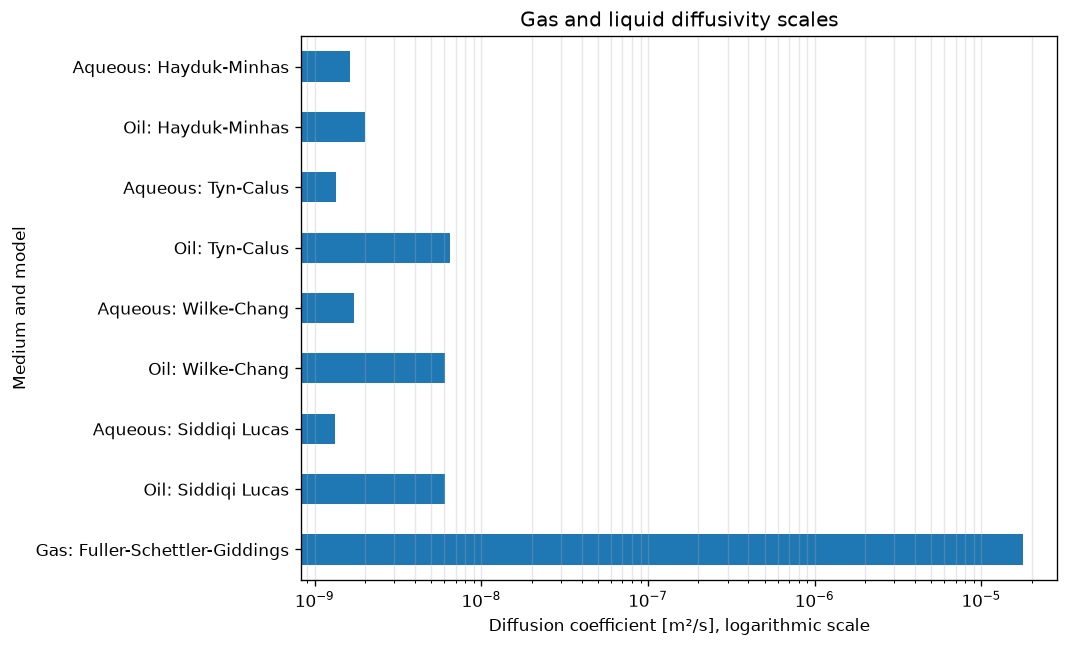

In [14]:
gas_reference_diffusivity = gas_model_table.loc[
    gas_model_table["Model"] == "Fuller-Schettler-Giddings",
    "Binary D(CO₂-methane) [m²/s]",
].iloc[0]
media_rows = [
    {
        "Medium and model": "Gas: Fuller-Schettler-Giddings",
        "Diffusivity [m²/s]": gas_reference_diffusivity,
    }
]

for _, liquid_row in liquid_model_table.iterrows():
    media_rows.append(
        {
            "Medium and model": f"Oil: {liquid_row['Model']}",
            "Diffusivity [m²/s]": liquid_row[
                "Oil D(n-hexane/n-heptane) [m²/s]"
            ],
        }
    )
    media_rows.append(
        {
            "Medium and model": f"Aqueous: {liquid_row['Model']}",
            "Diffusivity [m²/s]": liquid_row["Aqueous D(CO₂/water) [m²/s]"],
        }
    )

media_table = pd.DataFrame(media_rows)
display(media_table)

ax = media_table.plot.barh(
    x="Medium and model",
    y="Diffusivity [m²/s]",
    figsize=(9, 5.5),
    legend=False,
    logx=True,
)
ax.set_xlabel("Diffusion coefficient [m²/s], logarithmic scale")
ax.set_title("Gas and liquid diffusivity scales")
ax.grid(axis="x", which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Area screening and film uncertainty

Suppose a device must transfer 1 kmol/h of CO₂ under the base composition driving force. Required
interfacial area is the target molar rate divided by predicted flux. Film thickness is rarely known
independently, so its sensitivity should be shown explicitly rather than buried in a chosen
coefficient.

   Film thickness [mm]  ...  Required area [m²]
0                 0.10  ...            1.008057
1                 0.25  ...            2.520144
2                 0.50  ...            5.040287
3                 1.00  ...           10.080575
4                 2.00  ...           20.161149

[5 rows x 4 columns]


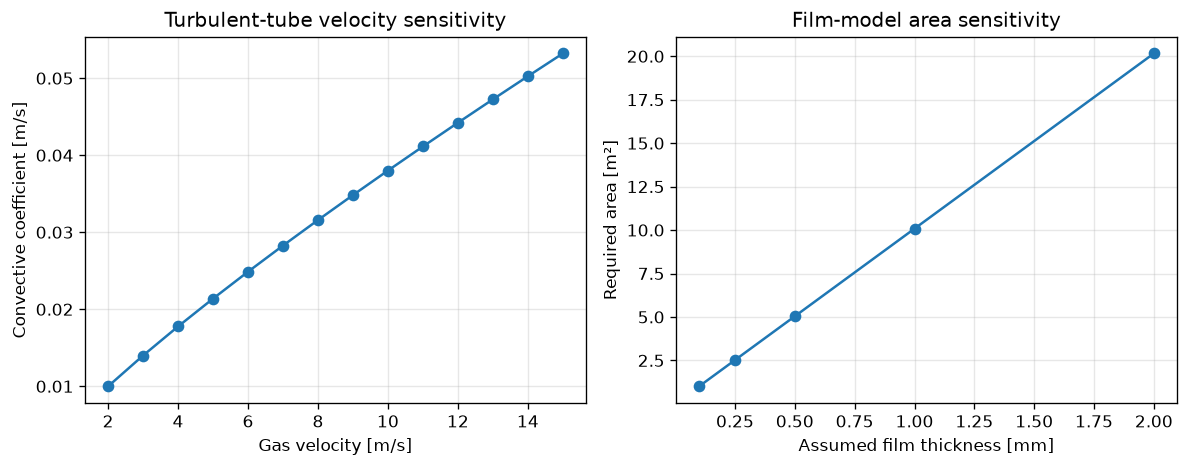

In [15]:
target_co2_rate_mol_per_s = 1000.0 / 3600.0
film_thickness_values_mm = np.array([0.10, 0.25, 0.50, 1.00, 2.00])
film_thickness_values_m = film_thickness_values_mm / 1000.0
film_coefficient_values = neqsim_effective_co2 / film_thickness_values_m
film_flux_values = film_coefficient_values * total_concentration_mol_per_m3
film_flux_values *= bulk_co2_fraction - interface_co2_fraction
required_area_values_m2 = target_co2_rate_mol_per_s / film_flux_values
removal_rate_check = film_flux_values * required_area_values_m2

area_table = pd.DataFrame(
    {
        "Film thickness [mm]": film_thickness_values_mm,
        "Film coefficient [m/s]": film_coefficient_values,
        "CO₂ flux [mol/(m² s)]": film_flux_values,
        "Required area [m²]": required_area_values_m2,
    }
)
display(area_table)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(velocity_values_m_per_s, coefficient_values_m_per_s, marker="o")
axes[0].set_xlabel("Gas velocity [m/s]")
axes[0].set_ylabel("Convective coefficient [m/s]")
axes[0].set_title("Turbulent-tube velocity sensitivity")
axes[1].plot(film_thickness_values_mm, required_area_values_m2, marker="o")
axes[1].set_xlabel("Assumed film thickness [mm]")
axes[1].set_ylabel("Required area [m²]")
axes[1].set_title("Film-model area sensitivity")

for axis in axes:
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Validation checks

The following assertions test numerical finiteness, expected gas trends, binary-matrix symmetry,
manual reconstruction of the effective coefficient, phase identification, liquid-property ranges,
dimensionless-correlation applicability, equimolar flux closure, and the area calculation. These are
focused regression checks, not experimental validation.

In [16]:
engineering_checks = {
    "feed composition sums to one": abs(composition_sum - 1.0) < 1.0e-12,
    "base state is one gas phase": gas_state.getNumberOfPhases() == 1,
    "gas density is finite and plausible": 0.1 < gas_density_kg_per_m3 < 20.0,
    "gas viscosity is finite and plausible": 1.0e-6 < gas_viscosity_pa_s < 1.0e-4,
    "gas correlations are positive": np.all(
        gas_model_table["Binary D(CO₂-methane) [m²/s]"] > 0.0
    ),
    "gas correlations stay in literature scale": np.all(
        gas_model_table["Binary D(CO₂-methane) [m²/s]"] < 1.0e-3
    ),
    "gas model spread stays below factor two": (
        gas_model_table["Binary D(CO₂-methane) [m²/s]"].max()
        / gas_model_table["Binary D(CO₂-methane) [m²/s]"].min()
        < 2.0
    ),
    "binary diffusion matrix is symmetric": np.allclose(
        binary_matrix,
        binary_matrix.T,
        rtol=1.0e-12,
        atol=0.0,
    ),
    "effective diffusivity reconstruction closes": effective_relative_error < 1.0e-12,
    "temperature raises gas diffusivity": np.all(np.diff(temperature_diffusivities) > 0.0),
    "pressure lowers gas diffusivity": np.all(np.diff(pressure_diffusivities) < 0.0),
    "film flux is toward the interface": co2_molar_flux > 0.0,
    "equimolar counterflux closes": abs(equimolar_flux_residual) < 1.0e-15,
    "tube correlation is turbulent": reynolds_number > 1.0e4,
    "Schmidt number is positive": schmidt_number > 0.0,
    "velocity increases convective transfer": np.all(
        np.diff(coefficient_values_m_per_s) > 0.0
    ),
    "hydrocarbon state contains oil": str(oil_phase.getPhaseTypeName()) == "oil",
    "water-rich state contains aqueous liquid": (
        str(aqueous_phase.getPhaseTypeName()) == "aqueous"
    ),
    "oil diffusivities are in liquid scale": np.all(
        liquid_model_table["Oil D(n-hexane/n-heptane) [m²/s]"].between(
            1.0e-12,
            1.0e-6,
        )
    ),
    "aqueous diffusivities are in liquid scale": np.all(
        liquid_model_table["Aqueous D(CO₂/water) [m²/s]"].between(
            1.0e-12,
            1.0e-6,
        )
    ),
    "gas diffusion exceeds every liquid result": gas_reference_diffusivity > (
        1000.0
        * max(
            liquid_model_table["Oil D(n-hexane/n-heptane) [m²/s]"].max(),
            liquid_model_table["Aqueous D(CO₂/water) [m²/s]"].max(),
        )
    ),
    "thicker films require more area": np.all(np.diff(required_area_values_m2) > 0.0),
    "area calculation reproduces target rate": np.allclose(
        removal_rate_check,
        target_co2_rate_mol_per_s,
        rtol=1.0e-12,
        atol=0.0,
    ),
}

failed_checks = [name for name, passed in engineering_checks.items() if not passed]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"
print(f"All {len(engineering_checks)} engineering checks passed.")

All 23 engineering checks passed.


## 13. Results summary and interpretation

The base gas correlations agree within a modest spread, and the expected temperature and pressure
trends hold. Liquid coefficients are several orders of magnitude smaller. The area result is highly
sensitive to assumed film thickness, illustrating why a molecular diffusion coefficient alone does
not determine equipment performance.

In [17]:
summary_table = pd.DataFrame(
    {
        "Result": [
            "Base binary D(CO₂-methane)",
            "Base effective D(CO₂)",
            "Film coefficient at 0.5 mm",
            "CO₂ flux at 0.5 mm",
            "Turbulent-tube coefficient at 8 m/s",
            "Required area at 0.5 mm",
            "Maximum effective-D reconstruction error",
        ],
        "Value": [
            gas_reference_diffusivity,
            neqsim_effective_co2,
            film_mass_transfer_coefficient,
            co2_molar_flux,
            convective_mass_transfer_coefficient,
            required_area_values_m2[2],
            effective_relative_error,
        ],
        "Unit": ["m²/s", "m²/s", "m/s", "mol/(m² s)", "m/s", "m²", "-"],
    }
)
display(summary_table)

                                     Result     Value        Unit
0                Base binary D(CO₂-methane)  0.000018        m²/s
1                     Base effective D(CO₂)  0.000017        m²/s
2                Film coefficient at 0.5 mm  0.033635         m/s
3                        CO₂ flux at 0.5 mm  0.055111  mol/(m² s)
4       Turbulent-tube coefficient at 8 m/s  0.031581         m/s
5                   Required area at 0.5 mm  5.040287          m²
6  Maximum effective-D reconstruction error  0.000000           -


## Limitations and applicability

- Diffusivity correlations are predictive estimates. Select and validate a model against data for
  the actual components, phase, and state.
- The simple film model assumes steady, one-dimensional diffusion, constant properties, a prescribed
  interface composition, and no reaction or Stefan-flow correction.
- The turbulent-tube Sherwood correlation is a screening relation, not a universal geometry model.
- SRK is suitable for the hydrocarbon gas screen. A tuned associating model is preferable for
  quantitative CO₂-water work.
- Rate-based absorber, membrane, reactive, porous-media, and multiphase designs require equilibrium,
  interfacial area, hydrodynamics, and possibly reaction kinetics in addition to molecular diffusion.

## Exercises and next steps

1. Replace the synthetic gas with a measured composition and compare the four gas correlations.
2. Repeat the pressure sweep at process pressure and check that the system remains single phase.
3. Replace the fixed interface CO₂ fraction with an equilibrium value from a flashed receiving phase.
4. Compare the tube correlation with a correlation appropriate to a packed column or membrane.

## References

- [NeqSim diffusivity models](https://github.com/equinor/neqsim/blob/master/docs/physical_properties/diffusivity_models.md)
- [NeqSim fluid-mechanics and mass-transfer overview](https://equinor.github.io/neqsim/fluidmechanics/)
- [NeqSim thermodynamic model guide](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- R. B. Bird, W. E. Stewart, and E. N. Lightfoot, *Transport Phenomena*, 2nd ed., 2002.
- E. N. Fuller, P. D. Schettler, and J. C. Giddings, *Industrial & Engineering Chemistry*, 58(5),
  1966, 18-27.